# Diabetes Glucose Regression
I wanted to predict glucose level from the rest of the Pima features. I rebuilt the workflow so the preprocessing stays inside the train-only pipeline and the saved scores are reproducible.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

sns.set_theme(style='whitegrid')

def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return Path(candidates[0])

DATA_PATH = first_existing_path(
    '../data/diabetes.csv',
    'data/diabetes.csv',
    'projects/diabetes-glucose-regression/data/diabetes.csv',
)
SUMMARY_PATH = first_existing_path(
    '../study_notes.json',
    'study_notes.json',
    'projects/diabetes-glucose-regression/study_notes.json',
)
RANDOM_STATE = 42

## Data checks
The raw file has a few impossible zeros. I treat `Glucose == 0` as an unusable target row, and I turn zero values in `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` into missing values before imputation.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,zero_count_in_raw,missing_pct_after_cleanup
Glucose,5,0.0
BloodPressure,35,4.6
SkinThickness,227,29.8
Insulin,374,48.5
BMI,11,1.4


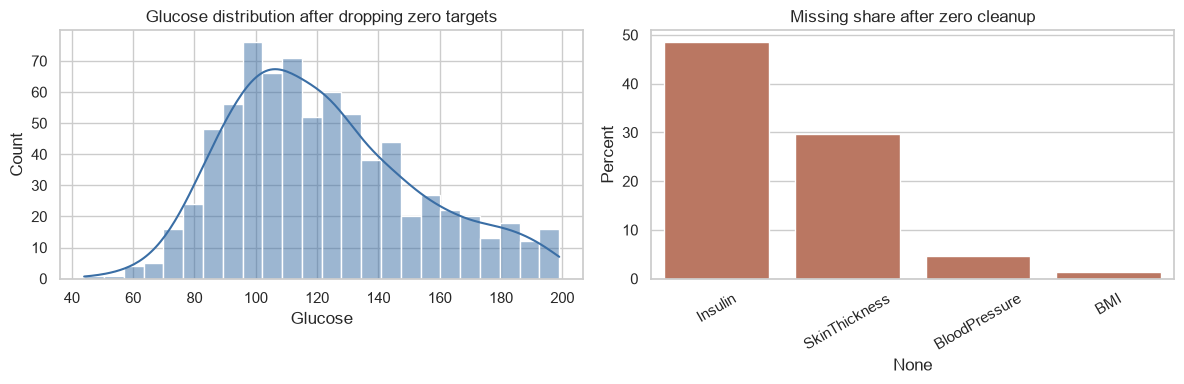

In [2]:
raw_df = pd.read_csv(DATA_PATH)
invalid_zero_cols = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = (raw_df[['Glucose', *invalid_zero_cols]] == 0).sum().rename('zero_count')

model_df = raw_df.loc[raw_df['Glucose'] > 0].copy()
for col in invalid_zero_cols:
    model_df[col] = model_df[col].replace(0, np.nan)

audit_table = pd.DataFrame({
    'zero_count_in_raw': zero_counts,
    'missing_pct_after_cleanup': model_df[['Glucose', *invalid_zero_cols]].isna().mean().mul(100).round(1)
})
display(raw_df.head())
display(audit_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(model_df['Glucose'], bins=24, kde=True, ax=axes[0], color='#3a6ea5')
axes[0].set_title('Glucose distribution after dropping zero targets')
axes[0].set_xlabel('Glucose')

missing_plot = model_df[invalid_zero_cols].isna().mean().mul(100).sort_values(ascending=False)
sns.barplot(x=missing_plot.index, y=missing_plot.values, ax=axes[1], color='#c96f53')
axes[1].set_title('Missing share after zero cleanup')
axes[1].set_ylabel('Percent')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [3]:
# I keep Outcome out because it is a diagnosis label tightly linked to glucose itself.
X = model_df.drop(columns=['Glucose', 'Outcome'])
y = model_df['Glucose']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    'rows': [len(raw_df), len(model_df), len(X_train), len(X_test)],
    'note': ['raw rows', 'usable rows after target cleanup', 'train split', 'test split']
}, index=['raw', 'clean', 'train', 'test'])
display(split_summary)

,rows,note
raw,768,raw rows
clean,763,usable rows after target cleanup
train,610,train split
test,153,test split


## Model comparison
I compare a dummy baseline, regularized linear models, KNN, SVR, random forest, and histogram gradient boosting. Each pipeline does its own median imputation, and the models that need scaling get it inside the pipeline so the test split never leaks into preprocessing.

,model,cv_rmse,cv_mae,cv_r2
0,Lasso,26.680,20.634,0.230
1,Ridge,26.683,20.629,0.230
2,Random forest,27.293,21.350,0.194
3,SVR,27.742,21.358,0.169
4,HistGBR,28.539,22.503,0.118
5,KNN,28.906,22.689,0.096
6,Dummy mean,30.596,24.705,-0.011


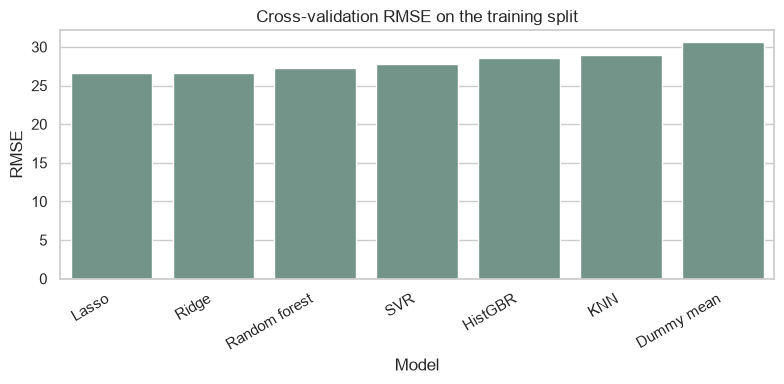

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scaled_prep = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
plain_prep = Pipeline([('imputer', SimpleImputer(strategy='median'))])

models = {
    'Dummy mean': Pipeline([('prep', plain_prep), ('model', DummyRegressor())]),
    'Ridge': Pipeline([('prep', scaled_prep), ('model', Ridge(alpha=3.0))]),
    'Lasso': Pipeline([('prep', scaled_prep), ('model', Lasso(alpha=0.2, max_iter=20000))]),
    'KNN': Pipeline([('prep', scaled_prep), ('model', KNeighborsRegressor(n_neighbors=9, weights='distance'))]),
    'SVR': Pipeline([('prep', scaled_prep), ('model', SVR(C=20, epsilon=5, gamma='scale'))]),
    'Random forest': Pipeline([('prep', plain_prep), ('model', RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1))]),
    'HistGBR': Pipeline([('prep', plain_prep), ('model', HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=400, random_state=RANDOM_STATE))]),
}

rows = []
for name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2',
        },
        n_jobs=1,
    )
    rows.append({
        'model': name,
        'cv_rmse': -scores['test_rmse'].mean(),
        'cv_mae': -scores['test_mae'].mean(),
        'cv_r2': scores['test_r2'].mean(),
    })

results_df = pd.DataFrame(rows).sort_values('cv_rmse').reset_index(drop=True)
best_name = results_df.loc[0, 'model']
display(results_df.round(3))

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='model', y='cv_rmse', color='#6c9a8b')
plt.title('Cross-validation RMSE on the training split')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Result notes
After removing 5 rows with impossible `Glucose = 0`, I still had 763 usable samples. `Insulin` was the noisiest input with 48.5% missing values, so keeping imputation inside each training fold mattered.

,metric,value
0,RMSE,25.412
1,MAE,19.371
2,R2,0.301


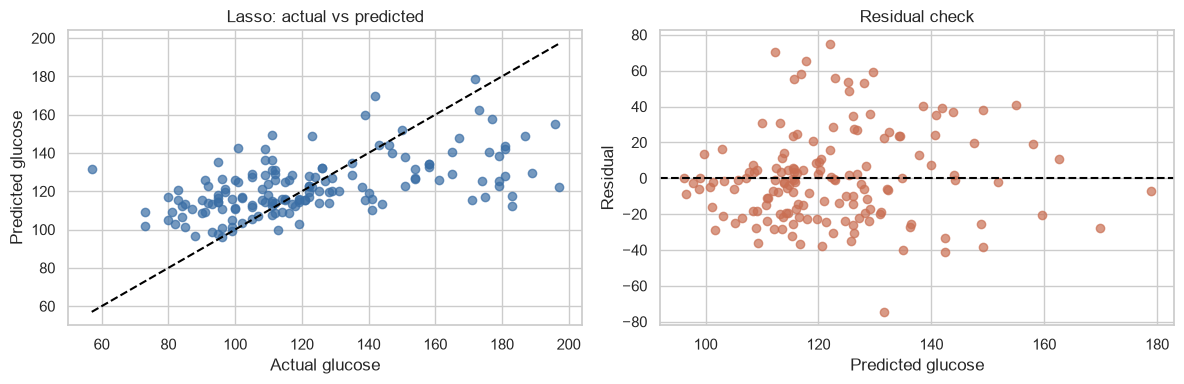

In [5]:
best_pipeline = models[best_name]
best_pipeline.fit(X_train, y_train)
test_pred = best_pipeline.predict(X_test)

test_metrics = pd.DataFrame({
    'metric': ['RMSE', 'MAE', 'R2'],
    'value': [
        float(np.sqrt(mean_squared_error(y_test, test_pred))),
        float(mean_absolute_error(y_test, test_pred)),
        float(r2_score(y_test, test_pred)),
    ],
})
display(test_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, test_pred, alpha=0.7, color='#3a6ea5')
line_min = min(y_test.min(), test_pred.min())
line_max = max(y_test.max(), test_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], '--', color='black')
axes[0].set_title(f'{best_name}: actual vs predicted')
axes[0].set_xlabel('Actual glucose')
axes[0].set_ylabel('Predicted glucose')

residuals = y_test - test_pred
axes[1].scatter(test_pred, residuals, alpha=0.7, color='#c96f53')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set_title('Residual check')
axes[1].set_xlabel('Predicted glucose')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

,feature,importance
3,Insulin,10.782
6,Age,6.480
4,BMI,3.281
1,BloodPressure,2.947
5,DiabetesPedigreeFunction,1.420


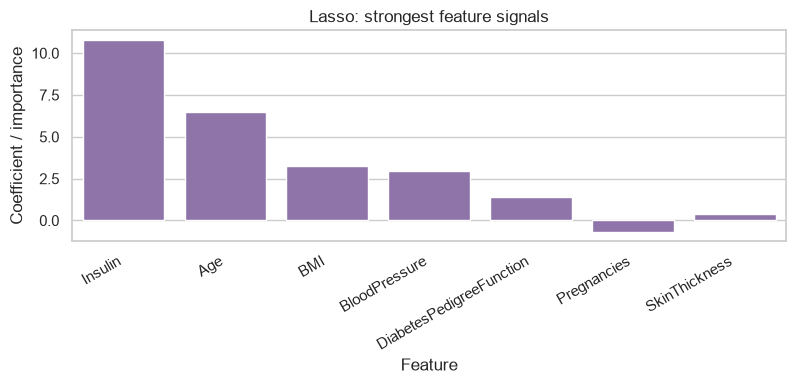

{'raw_rows': 768,
 'clean_rows': 763,
 'dropped_zero_glucose_rows': 5,
 'insulin_missing_pct': 48.492791612057665,
 'best_model': 'Lasso',
 'best_cv_rmse': 26.679968014565805,
 'dummy_test_rmse': 30.40124045872118,
 'test_rmse': 25.41231888844687,
 'test_r2': 0.30107535331335633,
 'top_feature': 'Insulin',
 'second_feature': 'Age'}

In [6]:
final_model = best_pipeline.named_steps['model']
feature_names = X.columns
if hasattr(final_model, 'coef_'):
    importance_values = np.ravel(final_model.coef_)
else:
    importance_values = np.ravel(final_model.feature_importances_)

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importance_values})
    .assign(abs_importance=lambda frame: frame['importance'].abs())
    .sort_values('abs_importance', ascending=False)
)
display(importance_df[['feature', 'importance']].head().round(3))

plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df.head(7), x='feature', y='importance', color='#8f6bb3')
plt.title(f'{best_name}: strongest feature signals')
plt.xlabel('Feature')
plt.ylabel('Coefficient / importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

summary = {
    'raw_rows': int(len(raw_df)),
    'clean_rows': int(len(model_df)),
    'dropped_zero_glucose_rows': int((raw_df['Glucose'] == 0).sum()),
    'insulin_missing_pct': float(model_df['Insulin'].isna().mean() * 100),
    'best_model': str(best_name),
    'best_cv_rmse': float(results_df.loc[0, 'cv_rmse']),
    'dummy_test_rmse': float(np.sqrt(mean_squared_error(y_test, models['Dummy mean'].fit(X_train, y_train).predict(X_test)))),
    'test_rmse': float(test_metrics.loc[test_metrics['metric'] == 'RMSE', 'value'].iloc[0]),
    'test_r2': float(test_metrics.loc[test_metrics['metric'] == 'R2', 'value'].iloc[0]),
    'top_feature': str(importance_df.iloc[0]['feature']),
    'second_feature': str(importance_df.iloc[1]['feature']),
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary

## What I learned
The simple regularized linear models were the most stable here. `Lasso` had the best cross-validation RMSE at about 26.68 and reached a test RMSE of 25.41 with R² near 0.30.

The dummy baseline stayed around 30.40 RMSE, so the notebook does learn a real signal. The feature view also pushed `Insulin` and `Age` to the top, which made me trust the linear pattern more than the heavier nonlinear models on this small dataset.